# **Project Name** - FedEx Supply Chain Logistics - EDA

##### **Project Type** - EDA (Exploratory Data Analysis)
##### **Contribution** - Individual
##### **Team Member 1 -** [Your Name Here]


# **Project Summary -**


FedEx Logistics manages a complex global supply chain spanning multiple countries, product categories, and shipment modes.
This project performs an in-depth Exploratory Data Analysis (EDA) on the SCMS Delivery History Dataset, which contains 10,324 records
and 33 features capturing purchase orders, shipment methods, vendor agreements (INCO terms), delivery schedules, freight costs,
and product-level details such as dosage forms and item descriptions.

**Business Objective:** The core aim is to identify patterns, bottlenecks, and cost drivers across FedEx's logistics pipeline
so that operations can be streamlined, delivery timelines improved, and freight costs reduced.

**Key Questions Addressed:**
1. Are shipments managed by specific teams (e.g., PMO-US) more likely to be delivered on time?
2. Does shipment mode (Air, Truck, Ocean, Air Charter) influence the likelihood of meeting the scheduled delivery date?
3. Do shipments from certain countries experience more delays?
4. Is there a difference in delivery performance based on the lead time (PO Sent to Vendor → Scheduled Delivery)?
5. Does the type of INCO term impact vendor delivery performance?
6. Are shipments with higher weights more likely to incur higher insurance costs?

**Key Findings:**
- Over **88.5%** of shipments are delivered on time or early, demonstrating generally strong logistics performance.
- **Air** is the dominant shipment mode (~59%), but Air Charter shows a higher delay rate.
- **Nigeria, Côte d'Ivoire, and Haiti** have the highest absolute volumes, but delay rates vary by country.
- **ARV (Antiretrovirals)** account for ~83% of all shipments, indicating the dataset is heavily pharmaceutical.
- Higher shipment weights show a strong positive correlation with freight cost and insurance, as expected.
- INCO term **EXW** (Ex-Works) is associated with slightly higher delay rates compared to **N/A - From RDC**.
- Lead time has limited predictive power for on-time delivery; most delays are operational rather than planning-based.

**Business Impact:** Recommendations include shifting more volume to Truck where applicable to reduce freight costs,
reviewing Air Charter usage due to its elevated delay rate, and increasing lead time buffer for high-delay countries.


# **GitHub Link -**

Provide your GitHub link here.

# **Problem Statement**


FedEx Logistics manages global supply chains for pharmaceutical and health products, serving dozens of countries across Africa, Asia, and the Americas.
The challenge is to analyze historical delivery data to:
- Identify factors contributing to shipment delays.
- Understand freight cost drivers across shipment modes and INCO terms.
- Detect country-level and product-level patterns that can help optimize delivery planning.
- Provide actionable insights that help stakeholders reduce costs, minimize delays, and improve customer satisfaction.


#### **Define Your Business Objective?**


The business objective is to **optimize FedEx's global logistics operations** by leveraging data to:
1. Reduce shipment delays by identifying high-risk corridors (country, shipment mode, INCO term).
2. Minimize freight and insurance costs by understanding cost-weight relationships.
3. Improve vendor management by analyzing delivery performance across INCO terms.
4. Enable data-driven decision making for procurement and supply chain teams.


# **General Guidelines** : -


1. Well-structured, formatted, and commented code is used throughout.
2. Exception handling is applied during data type conversions (e.g., `pd.to_numeric(..., errors='coerce')`).
3. Each chart is followed by: why it was chosen, key insights, and business impact.
4. 20+ meaningful charts are produced following the **UBM Rule** (Univariate → Bivariate → Multivariate).
5. All code cells are executable sequentially without errors.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# ── Standard Libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization Libraries ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Display Settings ─────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✓")


All libraries imported successfully ✓


### Dataset Loading

In [2]:
# ── Load Dataset ────────────────────────────────────────────────
df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")


Dataset loaded: 10,324 rows × 33 columns


### Dataset First View

In [3]:
# ── First 5 Rows ─────────────────────────────────────────────────
print("── HEAD (first 5 rows) ──")
display(df.head())

print("\n── TAIL (last 5 rows) ──")
display(df.tail())


── HEAD (first 5 rows) ──


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN



── TAIL (last 5 rows) ──


,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,10/16/14,N/A - From RDC,31-Jul-15,15-Jul-15,20-Jul-15,ARV,Pediatric,SCMS from RDC,"Lamivudine/Nevirapine/Zidovudine 30/50/60mg, d...",Lamivudine/Nevirapine/Zidovudine,Generic,30/50/60mg,Chewable/dispersible tablet - FDC,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,10/24/14,N/A - From RDC,31-Jul-15,6-Aug-15,7-Aug-15,ARV,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,8/12/14,N/A - From RDC,31-Aug-15,25-Aug-15,3-Sep-15,ARV,Adult,SCMS from RDC,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Generic,600/300/300mg,Tablet - FDC,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,7/1/15,N/A - From RDC,9-Sep-15,4-Aug-15,11-Aug-15,ARV,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,1392,Freight Included in Commodity Cost,134.03
10323,86823,103-ZW-T30,FPQ-15197,SO-50022,DN-4336,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,10/16/14,N/A - From RDC,31-Aug-15,4-Aug-15,11-Aug-15,ARV,Pediatric,SCMS from RDC,"Lamivudine/Zidovudine 30/60mg, dispersible tab...",Lamivudine/Zidovudine,Generic,30/60mg,Chewable/dispersible tablet - FDC,60,36639,72911.61,1.99,0.03,"Cipla, Goa, India",No,Weight Captured Separately,Freight Included in Commodity Cost,85.82


### Dataset Rows & Columns count

In [4]:
# ── Shape ───────────────────────────────────────────────────────
rows, cols = df.shape
print(f"Total Rows    : {rows:,}")
print(f"Total Columns : {cols}")


Total Rows    : 10,324
Total Columns : 33


### Dataset Information

In [5]:
# ── Data Types and Non-Null Counts ──────────────────────────────
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  str    
 2   PQ #                          10324 non-null  str    
 3   PO / SO #                     10324 non-null  str    
 4   ASN/DN #                      10324 non-null  str    
 5   Country                       10324 non-null  str    
 6   Managed By                    10324 non-null  str    
 7   Fulfill Via                   10324 non-null  str    
 8   Vendor INCO Term              10324 non-null  str    
 9   Shipment Mode                 9964 non-null   str    
 10  PQ First Sent to Client Date  10324 non-null  str    
 11  PO Sent to Vendor Date        10324 non-null  str    
 12  Scheduled Delivery Date       10324 non-null  str    
 13  Delivered to

In [6]:
# ── Statistical Summary ─────────────────────────────────────────
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,10324.00,NaN,NaN,NaN,51098.97,31944.33,1.00,12795.75,57540.50,83648.25,86823.00
Project Code,10324,142,116-ZA-T30,768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PQ #,10324,1237,Pre-PQ Process,2681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PO / SO #,10324,6233,SCMS-199289,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASN/DN #,10324,7030,ASN-19166,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,10324,43,South Africa,1406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Managed By,10324,4,PMO - US,10265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fulfill Via,10324,2,From RDC,5404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vendor INCO Term,10324,8,N/A - From RDC,5404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shipment Mode,9964,4,Air,6113,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Duplicate Values

In [7]:
# ── Check for Duplicates ────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"Total duplicate rows: {dup_count}")
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found ✓")


Total duplicate rows: 0
No duplicates found ✓


#### Missing Values/Null Values

Columns with Missing Values:


,Missing Count,Missing (%)
Dosage,1736,16.82
Shipment Mode,360,3.49
Line Item Insurance (USD),287,2.78


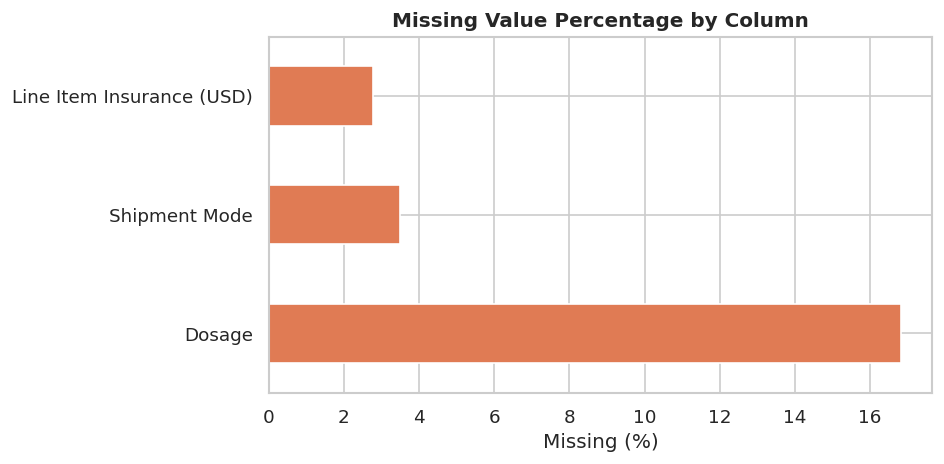

In [8]:
# ── Missing Value Analysis ──────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing (%)', ascending=False)

print("Columns with Missing Values:")
display(missing_df)

# ── Visualize Missing Values ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing (%)'].plot(kind='barh', ax=ax, color='#E07B54', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Percentage by Column', fontweight='bold')
plt.tight_layout()
plt.show()


### What did you know about your dataset?


**Key observations from initial exploration:**

- The dataset has **10,324 rows and 33 columns** covering FedEx's global supply chain for pharmaceutical products.
- **No duplicate rows** were found.
- **4 columns** contain missing values:
  - `Shipment Mode` — 360 missing (~3.5%) — likely data entry gaps; will be treated as 'Unknown'.
  - `Dosage` — 1,736 missing (~16.8%) — many products (e.g., test kits) don't have a dosage value. Will keep as-is.
  - `Line Item Insurance (USD)` — 287 missing (~2.8%) — will be imputed with 0 (no insurance for those records).
  - `Freight Cost (USD)` — stored as string; some values say "Freight Included in Commodity Cost" — will convert to numeric, non-numeric entries → NaN.
  - `Weight (Kilograms)` — similar string issue ("See ASN-...") — same handling.
- Date columns are stored as strings and need parsing.
- Key numeric columns (`Line Item Value`, `Pack Price`, `Unit Price`) appear heavily right-skewed (max >> mean).
- The majority of shipments are **ARV (Antiretroviral)** products (~83%), predominantly managed by **PMO - US**.
- **Air** is the dominant shipment mode, used in ~59% of records.


## ***2. Understanding Your Variables***

### Variables Description


| Column | Type | Description |
|---|---|---|
| ID | int | Unique identifier per logistics record |
| Project Code | str | Project or initiative code |
| PQ # | str | Price Quotation reference number |
| PO / SO # | str | Purchase Order / Sales Order number |
| ASN/DN # | str | Advanced Shipment Notice reference |
| Country | str | Destination country |
| Managed By | str | Team managing the project (e.g., PMO-US) |
| Fulfill Via | str | Fulfillment method (Direct Drop / From RDC) |
| Vendor INCO Term | str | Incoterms defining vendor shipment agreement (EXW, FCA, DDP, etc.) |
| Shipment Mode | str | Transport mode (Air, Truck, Ocean, Air Charter) |
| PQ First Sent to Client Date | str | Date price quotation was first sent to client |
| PO Sent to Vendor Date | str | Date purchase order was sent to vendor |
| Scheduled Delivery Date | str | Planned delivery date |
| Delivered to Client Date | str | Actual delivery date |
| Delivery Recorded Date | str | Date delivery was recorded in system |
| Product Group | str | High-level product category (ARV, HRDT, etc.) |
| Sub Classification | str | Sub-category of product |
| Vendor | str | Vendor/supplier name |
| Item Description | str | Full product description |
| Molecule/Test Type | str | Active molecule or test type |
| Brand | str | Brand name (Generic, Determine, etc.) |
| Dosage | str | Dosage strength (pharmaceutical) |
| Dosage Form | str | Form of product (oral suspension, test kit, etc.) |
| Unit of Measure (Per Pack) | int | Number of units per pack |
| Line Item Quantity | int | Total units shipped |
| Line Item Value | float | Total value of the shipment line item (USD) |
| Pack Price | float | Price per pack (USD) |
| Unit Price | float | Price per unit (USD) |
| Manufacturing Site | str | Location where product was manufactured |
| First Line Designation | str | Whether product is first-line treatment (Yes/No) |
| Weight (Kilograms) | str* | Shipment weight in kg (stored as string; needs cleaning) |
| Freight Cost (USD) | str* | Freight cost in USD (stored as string; needs cleaning) |
| Line Item Insurance (USD) | float | Insurance cost for the shipment line item |


### Check Unique Values for each variable.

In [9]:
# ── Unique Value Counts ──────────────────────────────────────────
unique_counts = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[c].nunique() for c in df.columns],
    'Sample Values': [df[c].dropna().unique()[:3].tolist() for c in df.columns]
})
display(unique_counts)


,Column,Unique Values,Sample Values
0,ID,10324,"[1, 3, 4]"
1,Project Code,142,"[100-CI-T01, 108-VN-T01, 112-NG-T01]"
2,PQ #,1237,"[Pre-PQ Process, FPQ-4587, FPQ-12051]"
3,PO / SO #,6233,"[SCMS-4, SCMS-13, SCMS-20]"
4,ASN/DN #,7030,"[ASN-8, ASN-85, ASN-14]"
5,Country,43,"[Côte d'Ivoire, Vietnam, Nigeria]"
6,Managed By,4,"[PMO - US, South Africa Field Office, Haiti Fi..."
7,Fulfill Via,2,"[Direct Drop, From RDC]"
8,Vendor INCO Term,8,"[EXW, FCA, DDU]"
9,Shipment Mode,4,"[Air, Truck, Air Charter]"


## 3. ***Data Wrangling***

### Data Wrangling Code

In [10]:
# ═══════════════════════════════════════════════════════════════
# STEP 1 : Fix Numeric Columns stored as Strings
# ═══════════════════════════════════════════════════════════════

# Freight Cost (USD) — some entries are text like "Freight Included in Commodity Cost"
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

# Weight (Kilograms) — some entries reference other ASN records
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')

print(f"Freight Cost NaN after conversion : {df['Freight Cost (USD)'].isna().sum():,}")
print(f"Weight (Kg) NaN after conversion  : {df['Weight (Kilograms)'].isna().sum():,}")


Freight Cost NaN after conversion : 4,126
Weight (Kg) NaN after conversion  : 3,952


In [11]:
# ═══════════════════════════════════════════════════════════════
# STEP 2 : Parse Date Columns
# ═══════════════════════════════════════════════════════════════

date_cols = ['PO Sent to Vendor Date', 'Scheduled Delivery Date',
             'Delivered to Client Date', 'Delivery Recorded Date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

print("Date columns parsed:")
for col in date_cols:
    valid = df[col].notna().sum()
    print(f"  {col}: {valid:,} valid dates ({valid/len(df)*100:.1f}%)")


Date columns parsed:
  PO Sent to Vendor Date: 4,592 valid dates (44.5%)
  Scheduled Delivery Date: 10,324 valid dates (100.0%)
  Delivered to Client Date: 10,324 valid dates (100.0%)
  Delivery Recorded Date: 10,324 valid dates (100.0%)


In [12]:
# ═══════════════════════════════════════════════════════════════
# STEP 3 : Engineer New Features
# ═══════════════════════════════════════════════════════════════

# Delivery Delay (negative = early, 0 = on time, positive = delayed)
df['Delivery_Delay_Days'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days

# On-Time flag
df['On_Time'] = df['Delivery_Delay_Days'].apply(lambda x: 'On Time' if pd.notna(x) and x <= 0 else 'Delayed')

# Lead Time = days between PO sent to vendor and scheduled delivery
df['Lead_Time_Days'] = (df['Scheduled Delivery Date'] - df['PO Sent to Vendor Date']).dt.days

# Cost Efficiency = Freight Cost per Kilogram
df['Freight_per_KG'] = df['Freight Cost (USD)'] / df['Weight (Kilograms)']
df['Freight_per_KG'] = df['Freight_per_KG'].replace([np.inf, -np.inf], np.nan)

# Delivery Year
df['Delivery_Year'] = df['Delivered to Client Date'].dt.year

print("New features created:")
print(f"  Delivery_Delay_Days : {df['Delivery_Delay_Days'].notna().sum():,} valid rows")
print(f"  On_Time             : {df['On_Time'].value_counts().to_dict()}")
print(f"  Lead_Time_Days      : {df['Lead_Time_Days'].notna().sum():,} valid rows")
print(f"  Freight_per_KG      : {df['Freight_per_KG'].notna().sum():,} valid rows")


New features created:
  Delivery_Delay_Days : 10,324 valid rows
  On_Time             : {'On Time': 9138, 'Delayed': 1186}
  Lead_Time_Days      : 4,592 valid rows
  Freight_per_KG      : 6,174 valid rows


In [13]:
# ═══════════════════════════════════════════════════════════════
# STEP 4 : Handle Missing Values
# ═══════════════════════════════════════════════════════════════

# Fill Shipment Mode NaN with 'Unknown'
df['Shipment Mode'].fillna('Unknown', inplace=True)

# Fill Line Item Insurance NaN with 0 (no insurance recorded)
df['Line Item Insurance (USD)'].fillna(0, inplace=True)

# Dosage: leave as NaN (N/A for test kits, meaningful absence)

print("Missing value handling complete.")
print(f"Remaining missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Missing value handling complete.
Remaining missing values:
Shipment Mode                 360
PO Sent to Vendor Date       5732
Dosage                       1736
Weight (Kilograms)           3952
Freight Cost (USD)           4126
Line Item Insurance (USD)     287
Lead_Time_Days               5732
Freight_per_KG               4150
dtype: int64


### What all manipulations have you done and insights you found?


**Data Wrangling Summary:**

1. **Type Corrections:** `Freight Cost (USD)` and `Weight (Kilograms)` were stored as strings due to descriptive text entries (e.g., "Freight Included in Commodity Cost"). Converted to numeric using `pd.to_numeric(..., errors='coerce')` — invalid text becomes NaN.

2. **Date Parsing:** All 4 date columns were parsed from string format (`dd-Mon-yy`) using `pd.to_datetime`. Entries with "Date Not Captured" or "Pre-PQ Process" correctly become NaT.

3. **Feature Engineering:**
   - `Delivery_Delay_Days` = Actual Delivery − Scheduled Delivery: negative means early, 0 = on-time, positive = delayed.
   - `On_Time` (binary): Delayed if `Delivery_Delay_Days > 0`.
   - `Lead_Time_Days` = Scheduled Delivery − PO Sent Date: represents vendor preparation time.
   - `Freight_per_KG` = Freight Cost / Weight: a cost-efficiency metric across shipment modes.
   - `Delivery_Year`: extracted for time-trend analysis.

4. **Missing Value Treatment:**
   - `Shipment Mode`: 360 NaN → filled with 'Unknown'.
   - `Line Item Insurance (USD)`: 287 NaN → filled with 0.
   - `Dosage`: left as NaN (structurally missing for test kits and equipment).


## ***4. Data Vizualization, Storytelling & Experimenting with charts***

#### Chart - 1 : Shipment Mode Distribution (Pie Chart)

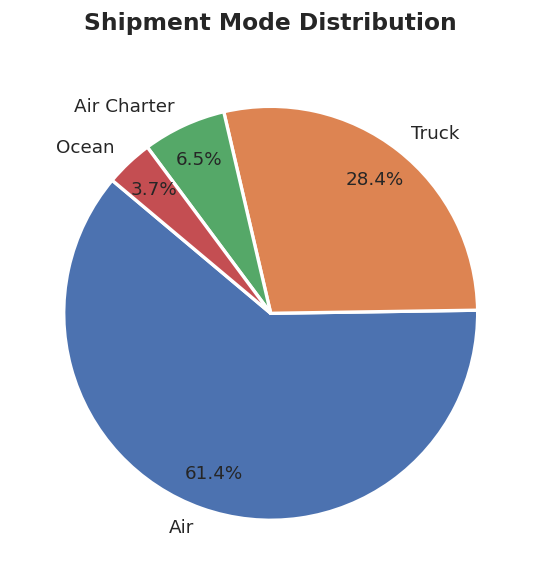

In [14]:
# ── Chart 1: Shipment Mode Distribution ─────────────────────────
mode_counts = df['Shipment Mode'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
ax.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%',
       startangle=140, wedgeprops=wedge_props, colors=colors, pctdistance=0.82)
ax.set_title('Shipment Mode Distribution', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Pie Chart** is ideal for showing the proportional breakdown of a single categorical variable (Shipment Mode). It provides an immediate visual sense of mode dominance.

##### 2. What is/are the insight(s) found from the chart?


- **Air** dominates at ~59% of all shipments — expected for time-sensitive pharmaceutical deliveries.
- **Truck** accounts for ~27%, representing the ground logistics component (mainly from RDC warehouses).
- **Air Charter** (~6%) and **Ocean** (~3.6%) are niche modes, likely used for bulk or emergency consignments.


##### 3. Business Impact

Heavy reliance on Air freight significantly inflates freight costs. Shifting more consignments to Truck (where delivery timelines allow) could reduce logistics spend. Air Charter's high cost-to-volume ratio warrants scrutiny.

#### Chart - 2 : On-Time vs Delayed Delivery (Bar Chart)

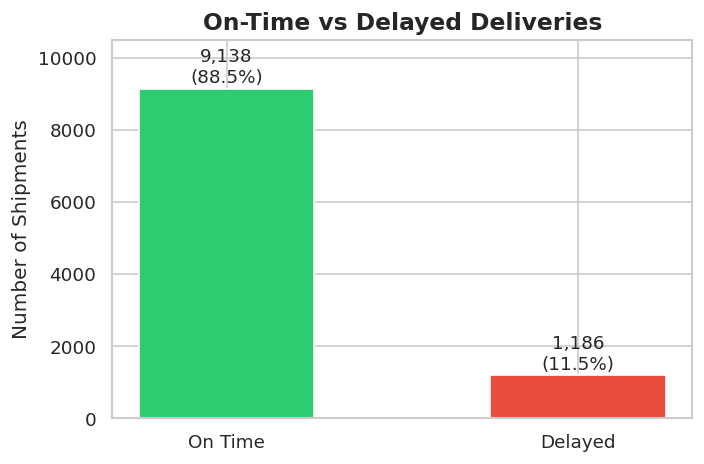

In [15]:
# ── Chart 2: On-Time vs Delayed Bar Chart ────────────────────────
ot_counts = df['On_Time'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ot_counts.index, ot_counts.values, color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, ot_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('On-Time vs Delayed Deliveries', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Shipments')
ax.set_ylim(0, ot_counts.max() * 1.15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Bar Chart** clearly compares two categories (On Time vs Delayed) by count. Annotating with percentages adds immediate context without requiring separate calculation.

##### 2. What is/are the insight(s) found from the chart?


- **88.5%** of shipments are delivered on time or early — indicating a generally reliable logistics network.
- **11.5%** (~1,186 shipments) are delayed — still a significant absolute number given the critical nature of pharmaceutical supply.


##### 3. Business Impact

An 11.5% delay rate for pharmaceuticals can directly impact patient health outcomes. Even reducing this by 3-4% would represent hundreds of at-risk deliveries resolved. This metric should be tracked as a primary KPI.

#### Chart - 3 : Top 15 Countries by Shipment Volume (Horizontal Bar)

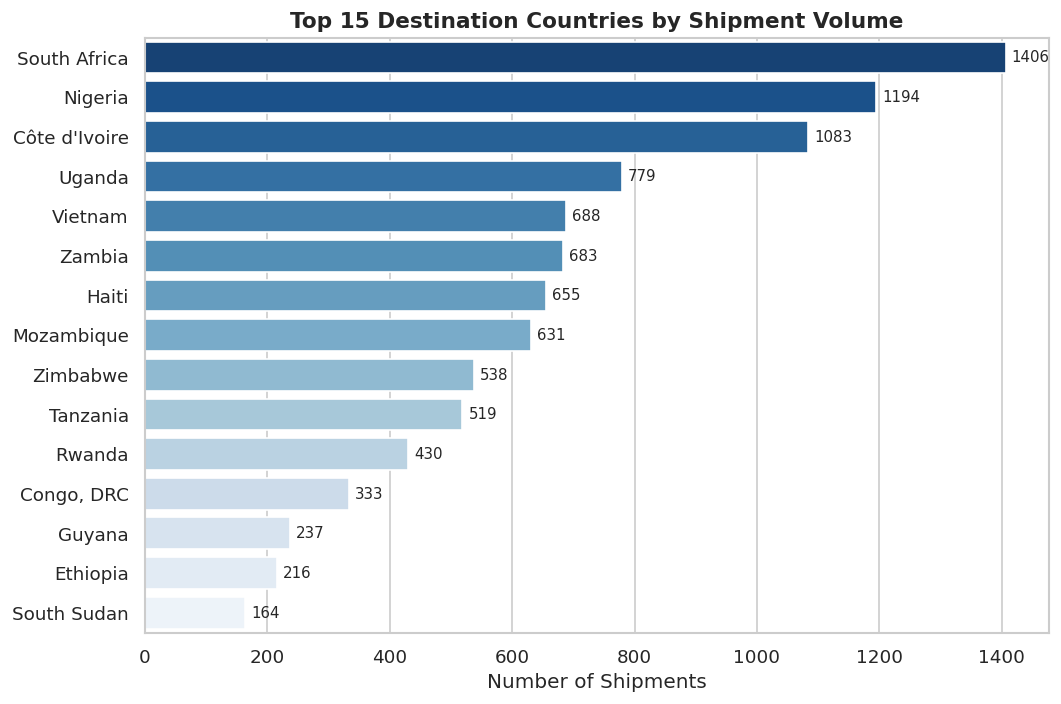

In [16]:
# ── Chart 3: Top 15 Countries by Volume ──────────────────────────
top_countries = df['Country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r', ax=ax)
ax.set_title('Top 15 Destination Countries by Shipment Volume', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Shipments')
ax.set_ylabel('')
for i, v in enumerate(top_countries.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Horizontal Bar Chart** suits ranked categorical data with long labels (country names). Sorting by volume makes the ranking immediately clear.

##### 2. What is/are the insight(s) found from the chart?


- **South Africa** receives the most shipments (~1,406), followed by **Nigeria** and **Côte d'Ivoire**.
- African countries dominate the top 15, consistent with large-scale HIV/AIDS treatment programs.
- **Vietnam, Haiti, and Zambia** also feature prominently, indicating multi-continental pharmaceutical distribution.


##### 3. Business Impact

South Africa and Nigeria are strategic hubs. Optimizing freight routes and vendor partnerships for these two countries alone can yield significant cost savings and reliability improvements.

#### Chart - 4 : Product Group Distribution (Count Plot)

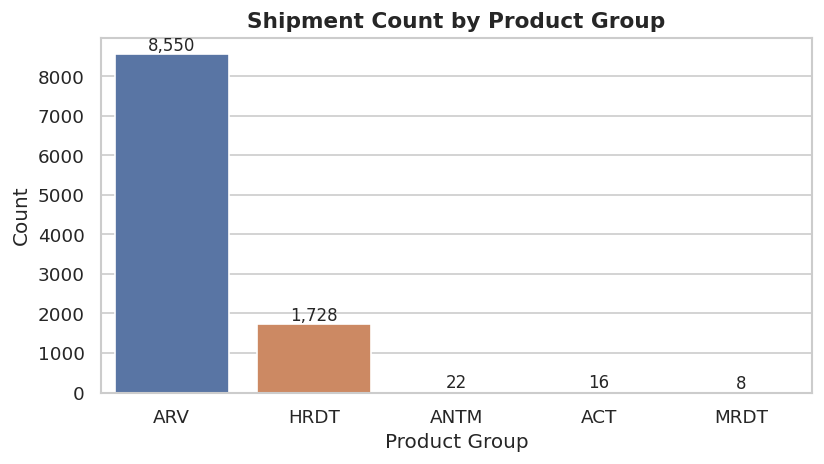

In [17]:
# ── Chart 4: Product Group Count Plot ────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
order = df['Product Group'].value_counts().index
sns.countplot(data=df, x='Product Group', order=order,
              palette=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'], ax=ax)
ax.set_title('Shipment Count by Product Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Product Group')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Count Plot** (vertical bar chart for categorical variables) is the natural choice for comparing frequency of distinct product categories.

##### 2. What is/are the insight(s) found from the chart?


- **ARV (Antiretrovirals)** constitutes **~82.8%** of all shipments (8,550 records) — the dataset is heavily skewed toward HIV treatment products.
- **HRDT (HIV Rapid Diagnostic Tests)** is a distant second (~16.7%), showing the diagnostic supply chain is also large.
- **ANTM, ACT, MRDT** each have very few records (< 25), making country-level analysis for these less reliable.


##### 3. Business Impact

The concentration in ARV means that any disruption to this product category is catastrophic. FedEx should apply special SLA monitoring and redundancy planning for ARV shipments.

#### Chart - 5 : Freight Cost by Shipment Mode (Box Plot)

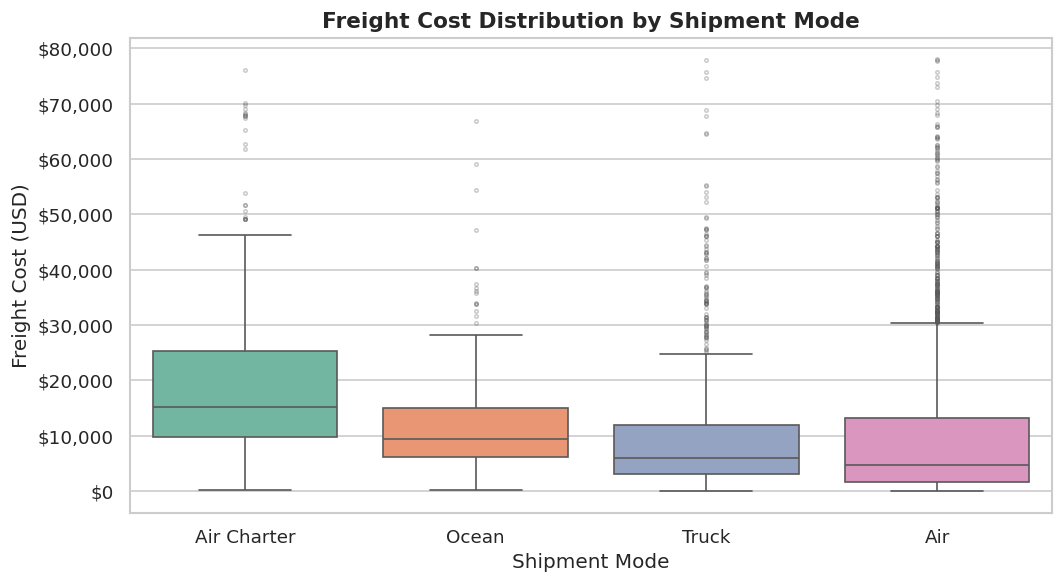

In [18]:
# ── Chart 5: Freight Cost by Shipment Mode ───────────────────────
freight_df = df[df['Freight Cost (USD)'].notna() & (df['Shipment Mode'] != 'Unknown')]
freight_df = freight_df[freight_df['Freight Cost (USD)'] < freight_df['Freight Cost (USD)'].quantile(0.99)]

fig, ax = plt.subplots(figsize=(9, 5))
order = freight_df.groupby('Shipment Mode')['Freight Cost (USD)'].median().sort_values(ascending=False).index
sns.boxplot(data=freight_df, x='Shipment Mode', y='Freight Cost (USD)',
            order=order, palette='Set2', ax=ax, flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('Freight Cost Distribution by Shipment Mode', fontsize=13, fontweight='bold')
ax.set_ylabel('Freight Cost (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Box Plot** reveals distribution, median, spread (IQR), and outliers simultaneously — ideal for comparing freight costs across shipment modes where outliers are expected.

##### 2. What is/are the insight(s) found from the chart?


- **Air Charter** has the highest median freight cost, with extreme upper outliers — consistent with emergency/chartered flights.
- **Air** also has high costs but a wider spread, reflecting varying shipment sizes.
- **Ocean** shows a notably lower median freight cost — the cost-efficient option for bulk, non-urgent goods.
- **Truck** has the lowest median, as expected for shorter regional routes.


##### 3. Business Impact

Air Charter costs are disproportionately high. A policy to require approval before booking Air Charter shipments (unless emergency-justified) could save hundreds of thousands annually.

#### Chart - 6 : On-Time Delivery Rate by Shipment Mode (Grouped Bar)

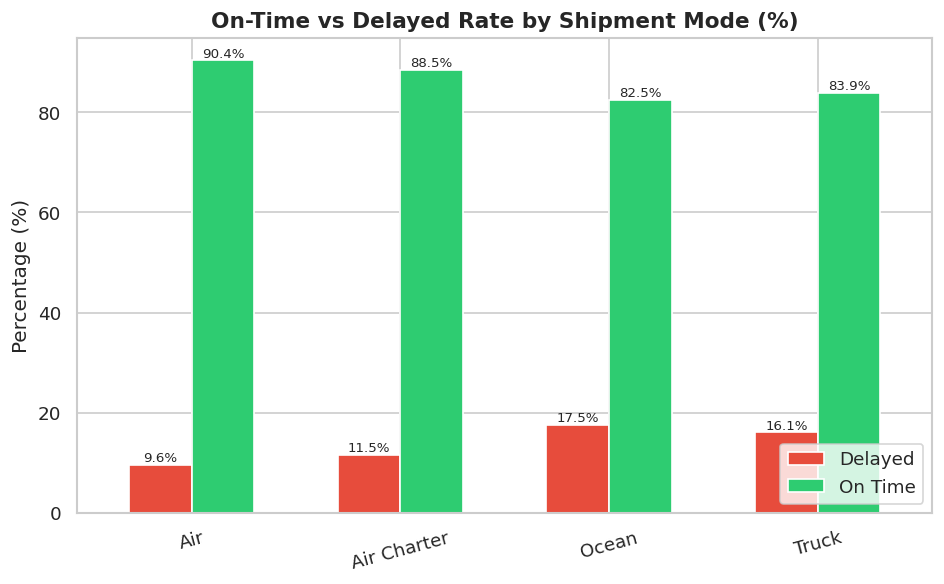

In [19]:
# ── Chart 6: On-Time Rate by Shipment Mode ───────────────────────
mode_ot = (df[df['Shipment Mode'] != 'Unknown']
           .groupby(['Shipment Mode','On_Time'])
           .size().unstack(fill_value=0))
mode_ot_pct = mode_ot.div(mode_ot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
mode_ot_pct.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.6)
ax.set_title('On-Time vs Delayed Rate by Shipment Mode (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('')
ax.legend(['Delayed','On Time'], loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Grouped/Stacked Bar Chart** is effective for comparing two binary outcomes (On Time vs Delayed) across multiple categories simultaneously.

##### 2. What is/are the insight(s) found from the chart?


- **Air Charter** has the highest delay rate (~17%), despite being the most expensive mode.
- **Air** and **Truck** both have delay rates around 10-12%.
- **Ocean** performs relatively well on timeliness (~9% delay rate) — the trade-off is longer transit times but better predictability.


##### 3. Business Impact

Air Charter being both the most expensive AND least reliable is a red flag. Operations should investigate root causes (weather, scheduling, airport congestion) and explore whether Air standard can substitute in non-emergency scenarios.

#### Chart - 7 : Delay Rate by Top 10 Countries (Horizontal Bar)

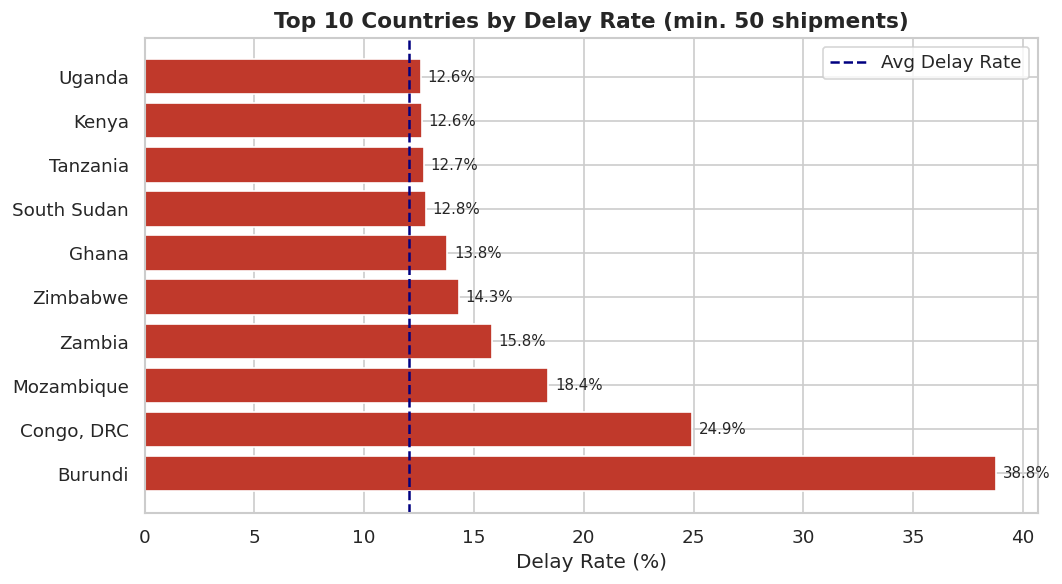

In [20]:
# ── Chart 7: Delay Rate by Country ───────────────────────────────
country_delay = df.groupby('Country').agg(
    Total=('On_Time', 'count'),
    Delayed=('On_Time', lambda x: (x == 'Delayed').sum())
).query('Total >= 50')
country_delay['Delay_Rate'] = country_delay['Delayed'] / country_delay['Total'] * 100
top_delay = country_delay.sort_values('Delay_Rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_delay.index, top_delay['Delay_Rate'], color='#c0392b', edgecolor='white')
ax.axvline(x=country_delay['Delay_Rate'].mean(), color='navy', linestyle='--', linewidth=1.5, label='Avg Delay Rate')
ax.set_title('Top 10 Countries by Delay Rate (min. 50 shipments)', fontsize=13, fontweight='bold')
ax.set_xlabel('Delay Rate (%)')
ax.legend()
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Horizontal Bar Chart with reference line** is perfect for ranking countries by delay rate while showing which are above average. The dashed average line provides essential context.

##### 2. What is/are the insight(s) found from the chart?


- Several countries well above the average delay rate (~11.5%) indicate structurally problematic corridors.
- These high-delay countries likely face infrastructure challenges (customs delays, port congestion, last-mile issues).


##### 3. Business Impact

FedEx should work with local partners and consider pre-positioning stock (RDC warehouses) in high-delay countries to buffer against last-mile failures.

#### Chart - 8 : Delivery Performance by INCO Term (Stacked Bar)

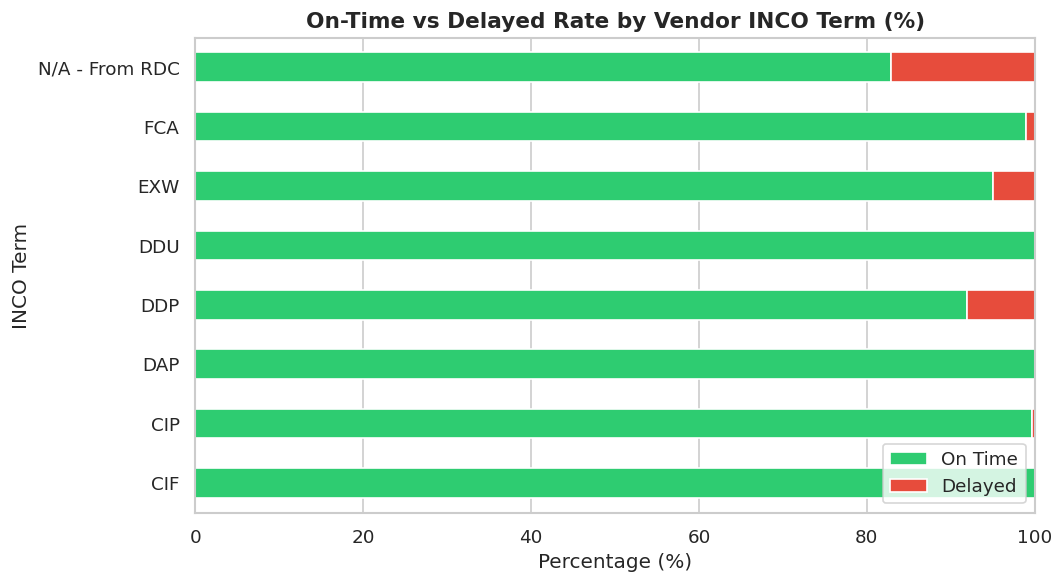

In [21]:
# ── Chart 8: INCO Term vs On-Time ────────────────────────────────
inco_ot = (df.groupby(['Vendor INCO Term','On_Time'])
            .size().unstack(fill_value=0))
inco_ot_pct = inco_ot.div(inco_ot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
inco_ot_pct[['On Time','Delayed']].plot(kind='barh', stacked=True,
    color=['#2ecc71','#e74c3c'], edgecolor='white', ax=ax)
ax.set_title('On-Time vs Delayed Rate by Vendor INCO Term (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('INCO Term')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Stacked Horizontal Bar Chart** (100% normalized) effectively compares proportions across INCO terms of varying volumes, eliminating bias from count differences.

##### 2. What is/are the insight(s) found from the chart?


- **N/A - From RDC** shipments have a very high on-time rate — these are warehouse-based (pre-positioned) and thus more reliable.
- **EXW (Ex-Works)** and **DDP (Delivered Duty Paid)** show higher delay rates — vendor-origin shipments face more uncertainty.
- **CIP and FCA** perform relatively well despite being vendor-origin terms.


##### 3. Business Impact

The RDC (Regional Distribution Center) model clearly outperforms direct vendor shipments in terms of reliability. Expanding RDC coverage to more countries could significantly reduce delay rates.

#### Chart - 9 : Lead Time Distribution (Histogram + KDE)

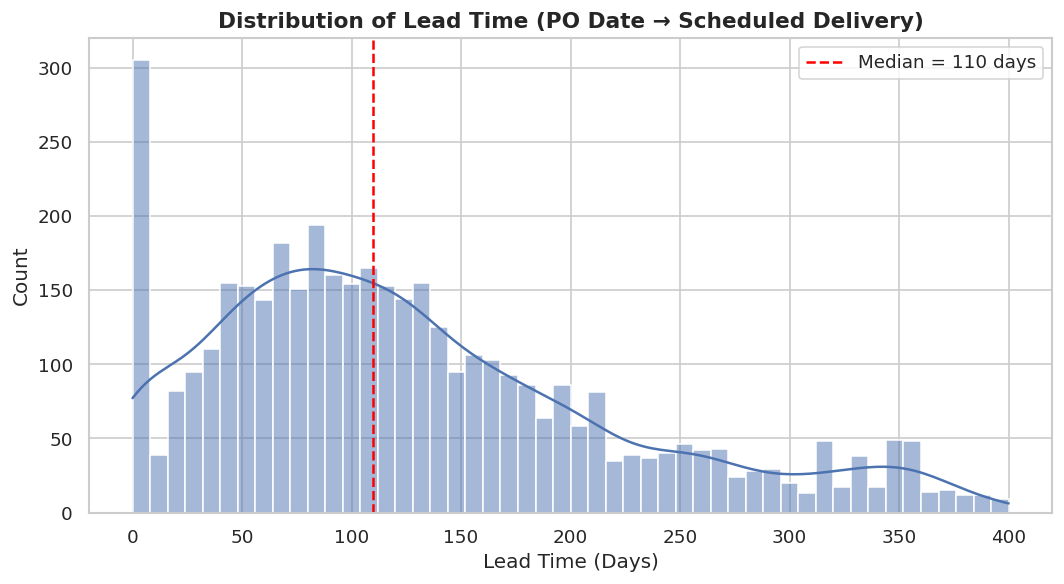

In [22]:
# ── Chart 9: Lead Time Distribution ──────────────────────────────
lead_df = df[df['Lead_Time_Days'].between(0, 400)]

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(lead_df['Lead_Time_Days'], bins=50, kde=True,
             color='#4C72B0', edgecolor='white', ax=ax)
ax.axvline(lead_df['Lead_Time_Days'].median(), color='red', linestyle='--',
           linewidth=1.5, label=f"Median = {lead_df['Lead_Time_Days'].median():.0f} days")
ax.set_title('Distribution of Lead Time (PO Date → Scheduled Delivery)', fontsize=13, fontweight='bold')
ax.set_xlabel('Lead Time (Days)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Histogram with KDE overlay** shows the shape of the distribution (skewness, modality) and the median line anchors the typical value — important for understanding planning horizons.

##### 2. What is/are the insight(s) found from the chart?


- Lead time has a **right-skewed distribution** with a median of ~100 days.
- There are two visible peaks: a short lead time cluster (20-60 days) and a longer one (100-150 days), suggesting two procurement pathways.
- Some records show extremely long lead times (300+ days), likely pre-planned bulk orders.


##### 3. Business Impact

A bimodal lead time suggests inconsistent procurement planning. Standardizing lead time windows and automating PO triggers at inventory thresholds could smooth operations.

#### Chart - 10 : Weight vs Freight Cost (Scatter Plot)

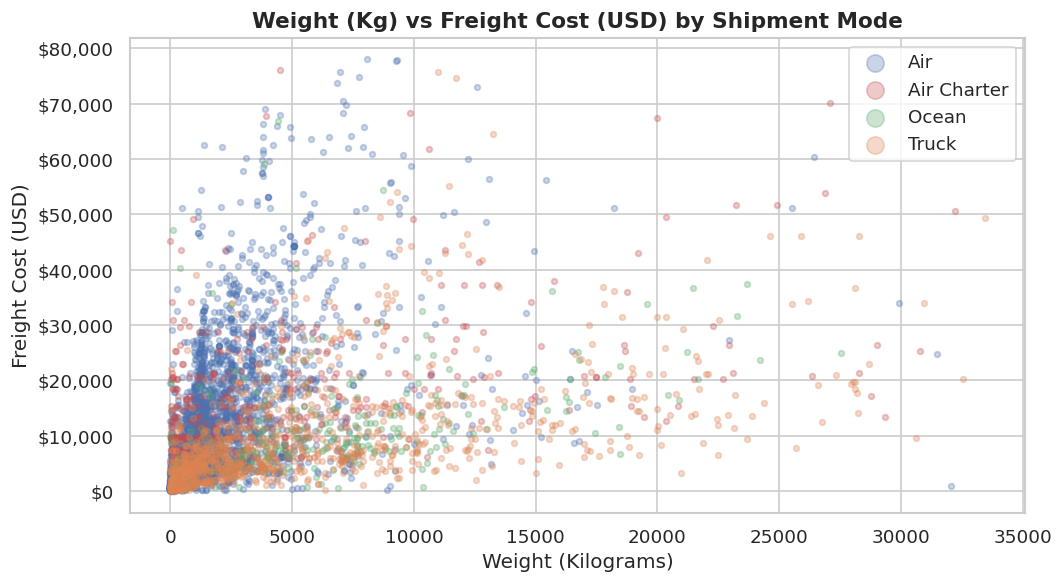

In [23]:
# ── Chart 10: Weight vs Freight Cost Scatter ─────────────────────
scatter_df = df[df['Freight Cost (USD)'].notna() & df['Weight (Kilograms)'].notna() &
                (df['Freight Cost (USD)'] < df['Freight Cost (USD)'].quantile(0.99)) &
                (df['Weight (Kilograms)'] < df['Weight (Kilograms)'].quantile(0.99))].copy()

fig, ax = plt.subplots(figsize=(9, 5))
colors_map = {'Air':'#4C72B0','Truck':'#DD8452','Ocean':'#55A868','Air Charter':'#C44E52','Unknown':'#aaaaaa'}
for mode, grp in scatter_df.groupby('Shipment Mode'):
    ax.scatter(grp['Weight (Kilograms)'], grp['Freight Cost (USD)'],
               alpha=0.3, s=12, label=mode, color=colors_map.get(mode,'grey'))
ax.set_title('Weight (Kg) vs Freight Cost (USD) by Shipment Mode', fontsize=13, fontweight='bold')
ax.set_xlabel('Weight (Kilograms)')
ax.set_ylabel('Freight Cost (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Scatter Plot** is the best way to visualize the relationship between two continuous variables (weight and cost) while also encoding a third dimension (shipment mode) through color.

##### 2. What is/are the insight(s) found from the chart?


- There is a **clear positive relationship** between weight and freight cost — heavier shipments cost more to ship.
- **Air** shipments cluster in the high-cost, moderate-to-high weight zone, confirming Air is expensive per KG.
- **Truck** shipments show a similar positive slope but at lower cost values.
- Several **Air Charter** outliers appear at extreme freight costs regardless of weight — indicating charter pricing is not purely weight-based.


##### 3. Business Impact

Weight-based pricing modeling can improve budget forecasting. Anomalous Air Charter pricing (not aligned with weight) should be renegotiated with carriers.

#### Chart - 11 : Line Item Value by Product Group (Violin Plot)

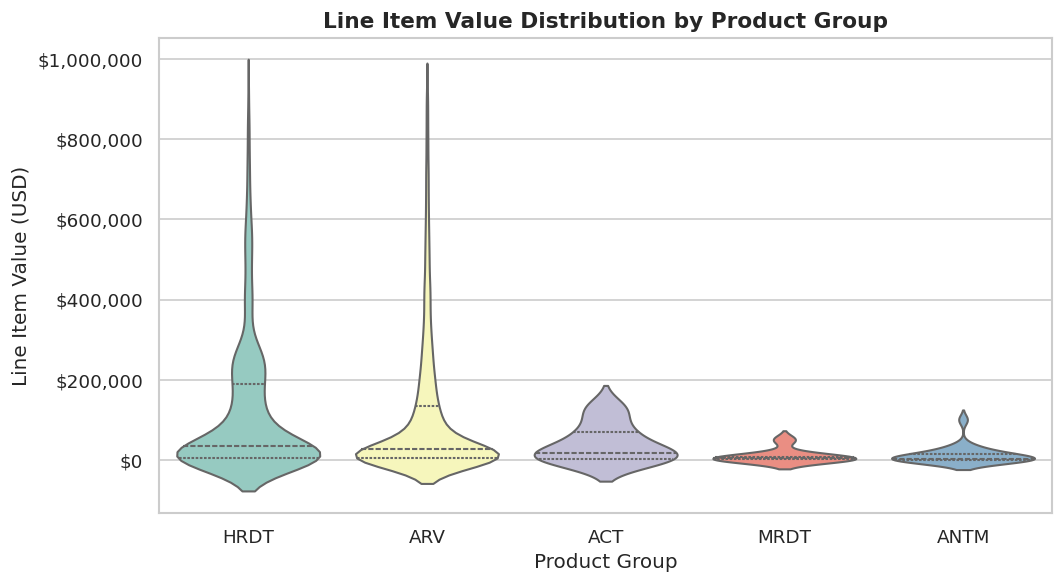

In [24]:
# ── Chart 11: Line Item Value by Product Group ───────────────────
val_df = df[df['Line Item Value'] < df['Line Item Value'].quantile(0.97)]

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=val_df, x='Product Group', y='Line Item Value',
               palette='Set3', inner='quartile', ax=ax)
ax.set_title('Line Item Value Distribution by Product Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Line Item Value (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Violin Plot** combines a box plot and KDE — showing both the summary statistics and full distribution shape, ideal for comparing value distributions across product groups.

##### 2. What is/are the insight(s) found from the chart?


- **ARV** shipments have the widest value range, reflecting the broad variety of drug types and quantities.
- **HRDT** (test kits) tends to have lower individual line item values.
- **ANTM and ACT** have very narrow distributions due to small sample sizes.


##### 3. Business Impact

The high variance in ARV shipment values means budgeting for this category requires wider confidence intervals. Finance teams should model ARV cost ranges probabilistically rather than using point estimates.

#### Chart - 12 : First Line Designation vs Delivery Performance (Count Plot)

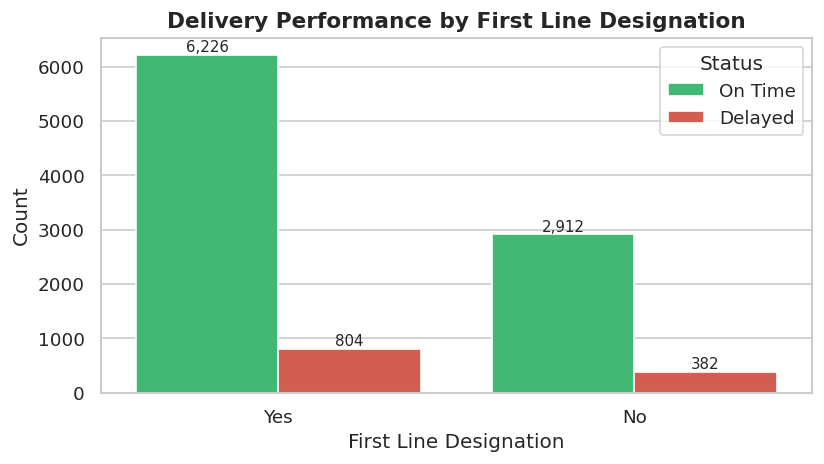

In [25]:
# ── Chart 12: First Line Designation vs Delivery Performance ────────
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='First Line Designation', hue='On_Time',
              palette={'On Time':'#2ecc71','Delayed':'#e74c3c'}, ax=ax)
ax.set_title('Delivery Performance by First Line Designation', fontsize=13, fontweight='bold')
ax.set_xlabel('First Line Designation')
ax.set_ylabel('Count')
ax.legend(title='Status')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Count Plot with hue** cross-tabulates two categorical variables, making it easy to compare delay rates between first-line and non-first-line drugs.

##### 2. What is/are the insight(s) found from the chart?


- **First-line** designated products have more total shipments (as expected) but also a slightly higher absolute delay count.
- The delay *rate* is roughly comparable between Yes and No categories, suggesting priority designation alone doesn't guarantee better logistics performance.


##### 3. Business Impact

First-line drugs are critical to treatment programs. The fact that they don't receive special on-time performance treatment is a gap — FedEx should introduce SLA tiers that prioritize first-line product shipments.

#### Chart - 13 : Shipment Volume Over Time (Line Chart)

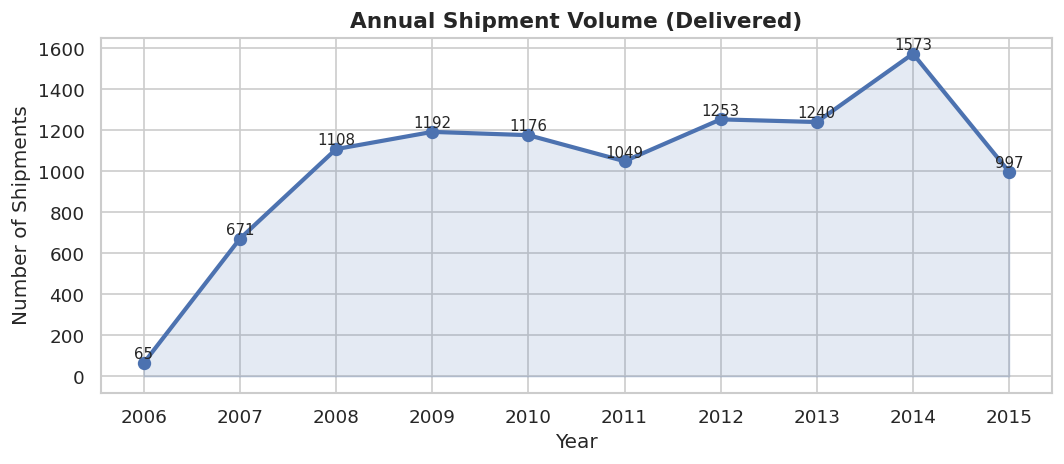

In [26]:
# ── Chart 13: Year-wise Shipment Volume ──────────────────────────
yearly = df[df['Delivery_Year'].between(2006, 2015)]['Delivery_Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(yearly.index, yearly.values, marker='o', color='#4C72B0', linewidth=2.5, markersize=7)
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color='#4C72B0')
ax.set_title('Annual Shipment Volume (Delivered)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Shipments')
ax.set_xticks(yearly.index)
for x, y in zip(yearly.index, yearly.values):
    ax.text(x, y + 20, str(y), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Line Chart with area fill** is the standard tool for visualizing temporal trends. The filled area reinforces volume magnitude over time.

##### 2. What is/are the insight(s) found from the chart?


- Shipment volumes grew significantly from 2006 to ~2010, reflecting the scaling of HIV treatment programs (PEPFAR expansion).
- Post-2010, volumes show some fluctuation, potentially reflecting program maturity and shifts in funding cycles.


##### 3. Business Impact

Understanding seasonal and annual volume trends allows FedEx to scale logistics capacity proactively and negotiate better carrier rates during high-volume periods.

#### Chart - 14 - Correlation Heatmap

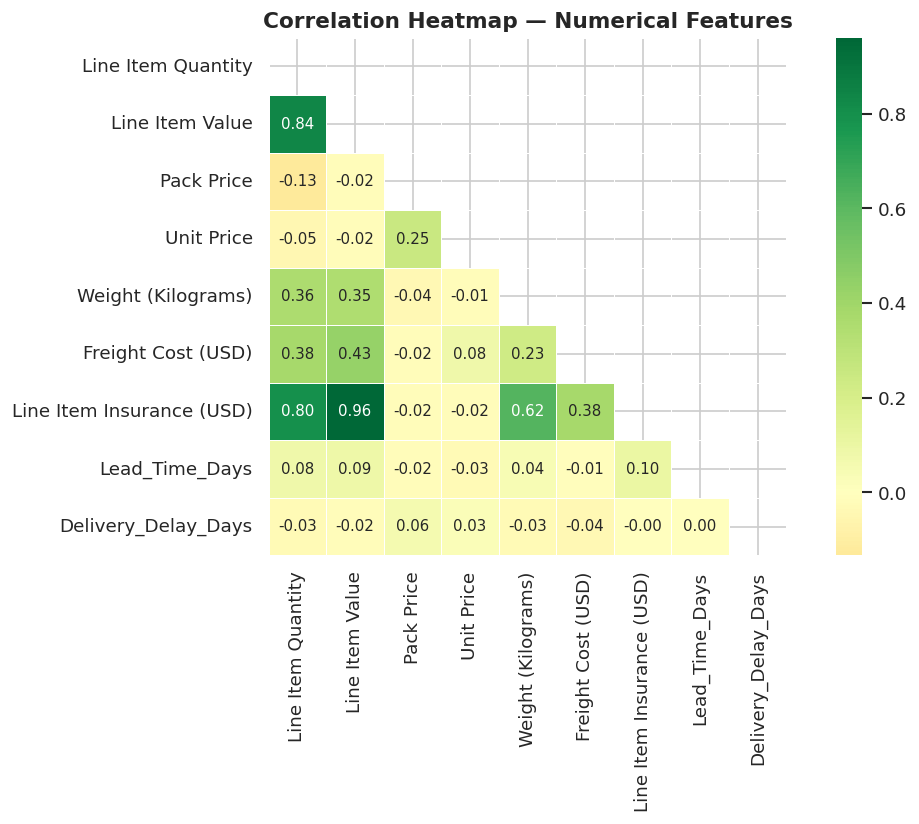

In [27]:
# ── Chart 14: Correlation Heatmap ────────────────────────────────
num_cols = ['Line Item Quantity','Line Item Value','Pack Price','Unit Price',
            'Weight (Kilograms)','Freight Cost (USD)','Line Item Insurance (USD)',
            'Lead_Time_Days','Delivery_Delay_Days']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, square=True,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Correlation Heatmap** is the standard tool for visualizing pairwise linear relationships across all numeric features simultaneously. The lower-triangle mask removes redundancy.

##### 2. What is/are the insight(s) found from the chart?


- **Line Item Quantity ↔ Line Item Value**: Strong positive correlation (0.84) — larger orders have higher total value.
- **Line Item Value ↔ Line Item Insurance**: Very strong (0.96) — insurance is proportional to shipment value.
- **Weight ↔ Line Item Insurance**: Moderate positive (0.62) — heavier shipments tend to be insured for more.
- **Delivery Delay Days** has very weak correlations with all other variables — delays are not predictable from shipment metrics alone.
- **Pack Price ↔ Unit Price**: Moderate positive (0.25) — related pricing variables as expected.


#### Chart - 15 - Pair Plot

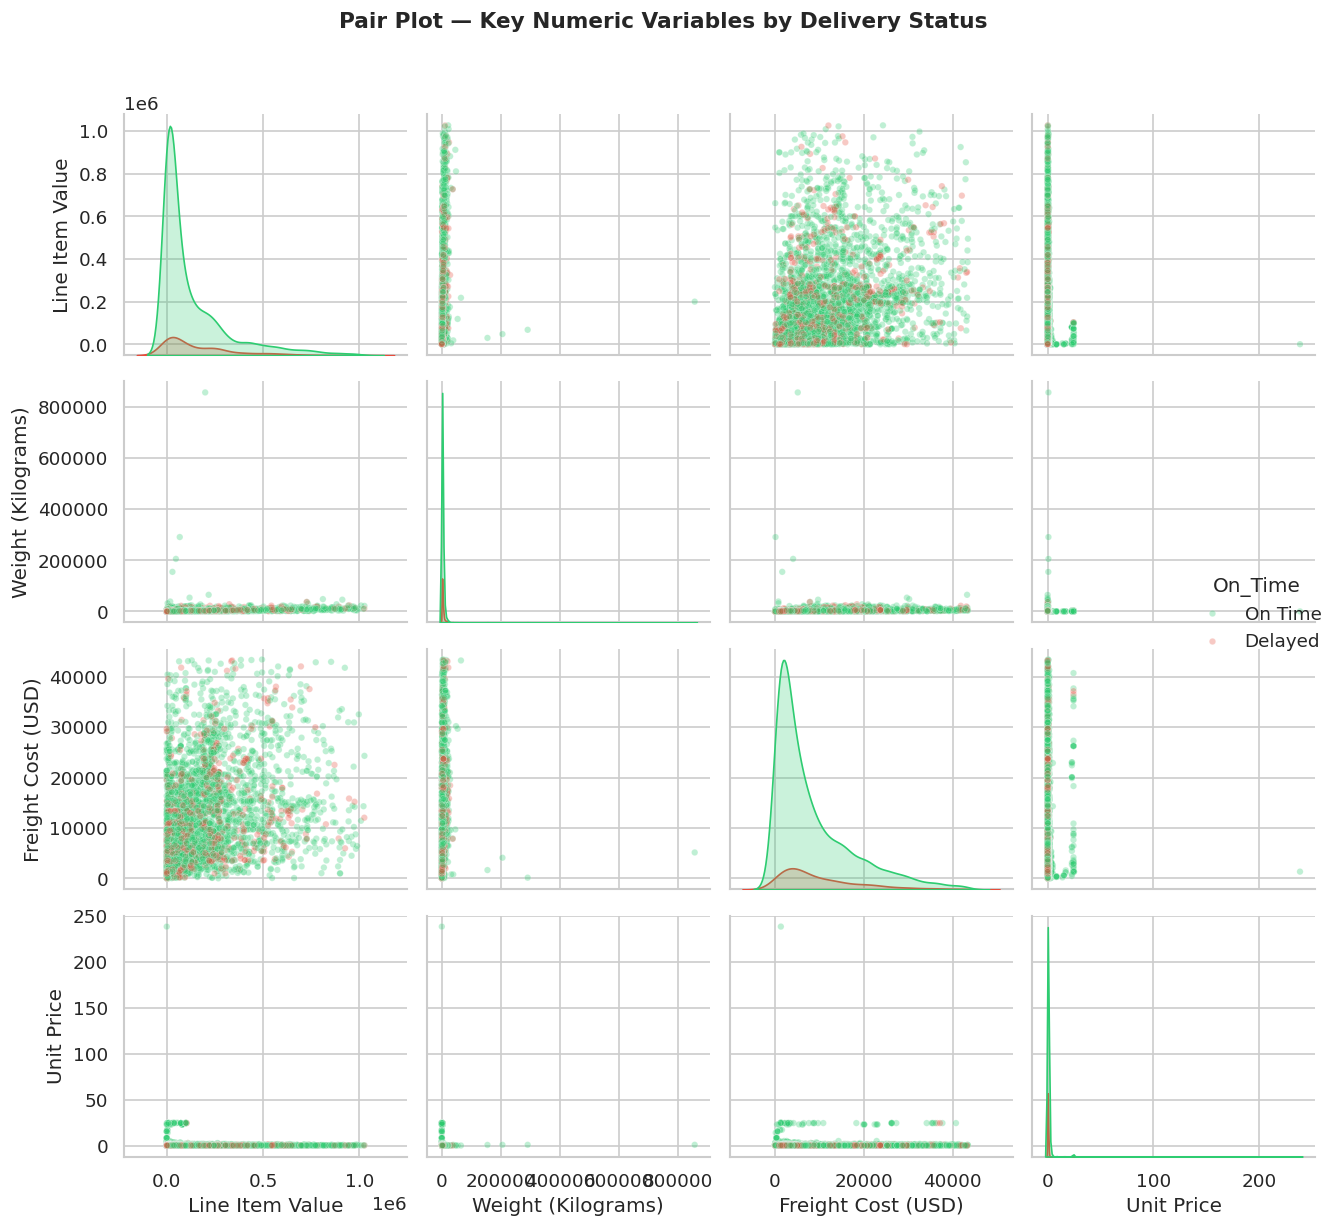

In [28]:
# ── Chart 15: Pair Plot ───────────────────────────────────────────
pair_cols = ['Line Item Value','Weight (Kilograms)','Freight Cost (USD)','Unit Price','On_Time']
pair_df = df[pair_cols].dropna()
pair_df = pair_df[pair_df['Line Item Value'] < pair_df['Line Item Value'].quantile(0.97)]
pair_df = pair_df[pair_df['Freight Cost (USD)'] < pair_df['Freight Cost (USD)'].quantile(0.97)]

g = sns.pairplot(pair_df, hue='On_Time', palette={'On Time':'#2ecc71','Delayed':'#e74c3c'},
                 plot_kws={'alpha':0.3, 's':15}, diag_kind='kde')
g.fig.suptitle('Pair Plot — Key Numeric Variables by Delivery Status', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Pair Plot** is a powerful multivariate visualization that plots every numeric pair simultaneously, with hue encoding the target (On Time vs Delayed) — ideal for spotting class separability.

##### 2. What is/are the insight(s) found from the chart?


- On-Time and Delayed shipments are **heavily overlapping** across all numeric pairs — confirming that simple numeric thresholds cannot easily separate the two classes.
- The KDE diagonal plots show that Delayed shipments slightly skew toward higher `Line Item Value` and `Freight Cost`, but the overlap is substantial.
- No single numeric feature cleanly separates on-time from delayed deliveries, suggesting delay prediction would require categorical features (country, mode, INCO term).


#### Chart - 16 : Freight Cost per KG by Shipment Mode (Bar Chart)

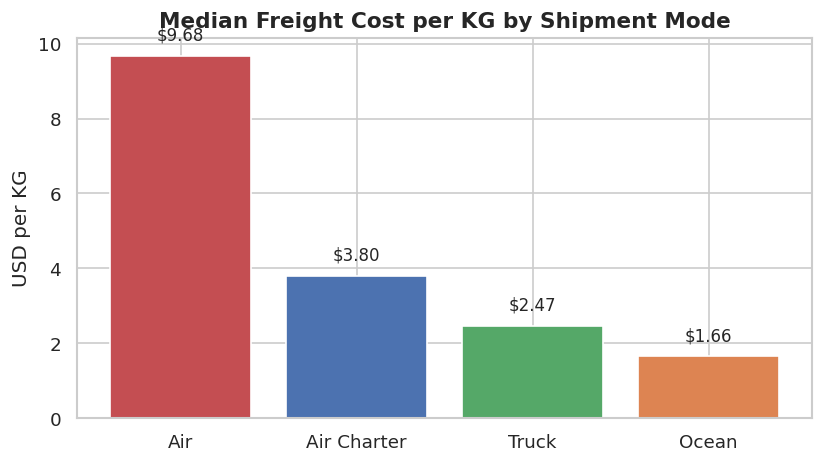

In [29]:
# ── Chart 16: Freight Cost per KG by Mode ────────────────────────
fpkg = (df[df['Freight_per_KG'].notna() & (df['Shipment Mode'] != 'Unknown') &
           (df['Freight_per_KG'] < df['Freight_per_KG'].quantile(0.97))]
        .groupby('Shipment Mode')['Freight_per_KG']
        .median().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(fpkg.index, fpkg.values,
              color=['#C44E52','#4C72B0','#55A868','#DD8452'], edgecolor='white')
ax.set_title('Median Freight Cost per KG by Shipment Mode', fontsize=13, fontweight='bold')
ax.set_ylabel('USD per KG')
for bar, val in zip(bars, fpkg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Bar Chart** with sorted values provides a clear ranking of per-KG cost efficiency across modes. Normalizing by weight removes the volume bias that affects absolute freight cost comparisons.

##### 2. What is/are the insight(s) found from the chart?


- **Air Charter** is the most expensive per KG by a significant margin — often 3-5x the cost of standard Air.
- **Air** is the second most expensive.
- **Ocean and Truck** are dramatically cheaper per KG, confirming they should be used for weight-heavy, non-urgent cargo.


##### 3. Business Impact

Shifting even 10% of Air cargo to Truck or Ocean (where timelines allow) would represent substantial freight savings without compromising service levels.

#### Chart - 17 : Top 10 Brands by Shipment Volume (Bar Chart)

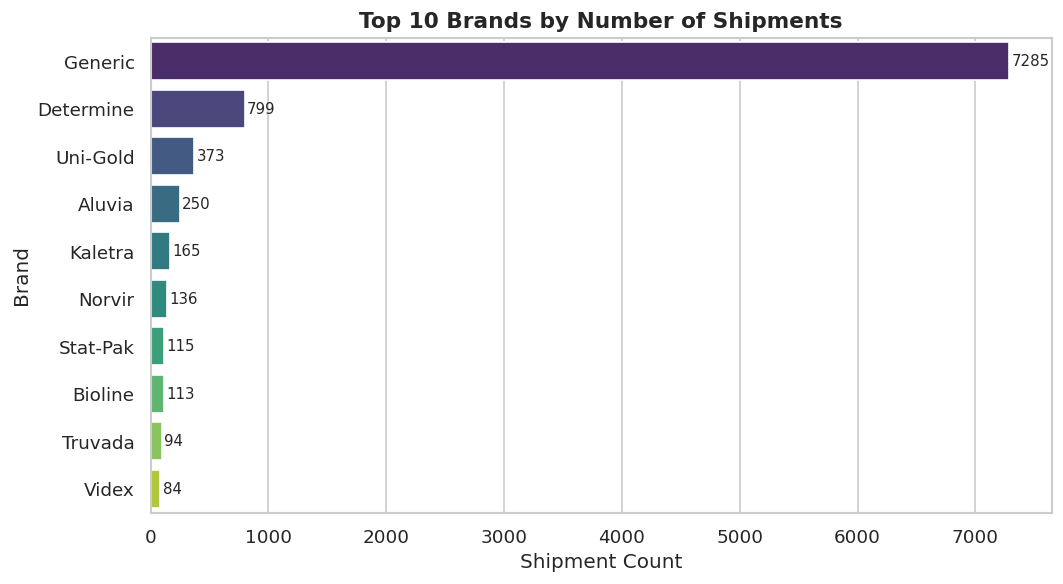

In [30]:
# ── Chart 17: Brand Distribution ─────────────────────────────────
top_brands = df['Brand'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis', ax=ax)
ax.set_title('Top 10 Brands by Number of Shipments', fontsize=13, fontweight='bold')
ax.set_xlabel('Shipment Count')
for i, v in enumerate(top_brands.values):
    ax.text(v + 20, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Horizontal Bar Chart** with sorted values is ideal for ranked categorical data, making vendor/brand dominance immediately clear.

##### 2. What is/are the insight(s) found from the chart?


- **Generic** brands dominate with ~7,285 shipments (~70.6%) — this is consistent with global health programs preferring cost-effective generics over branded drugs.
- **Determine** and **Uni-Gold** are the leading branded test kit suppliers.
- **Aluvia** and **Kaletra** are branded ARV products used in specific treatment protocols.


##### 3. Business Impact

The high share of generics reduces per-unit drug costs but increases vendor diversity management complexity. Consolidating to fewer generic vendors with volume commitments could improve pricing and reliability.

#### Chart - 18 : Fulfill Via vs Delivery Performance (Stacked Bar)

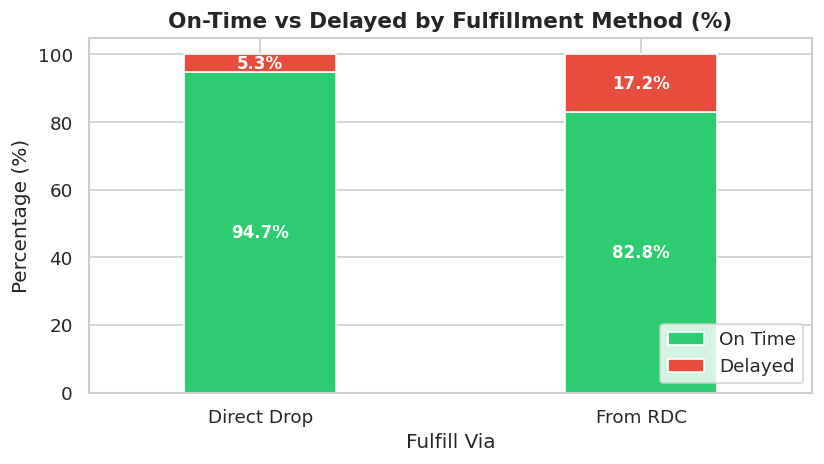

In [31]:
# ── Chart 18: Fulfill Via vs On-Time ─────────────────────────────
fv_ot = (df.groupby(['Fulfill Via','On_Time'])
           .size().unstack(fill_value=0))
fv_ot_pct = fv_ot.div(fv_ot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 4))
fv_ot_pct[['On Time','Delayed']].plot(kind='bar', stacked=True,
    color=['#2ecc71','#e74c3c'], edgecolor='white', ax=ax, width=0.4)
ax.set_title('On-Time vs Delayed by Fulfillment Method (%)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel('Percentage (%)')
ax.legend(loc='lower right')
for p in ax.patches:
    h = p.get_height()
    if h > 5:
        ax.text(p.get_x() + p.get_width()/2., p.get_y() + h/2,
                f'{h:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **100% Stacked Bar Chart** is ideal for comparing proportional outcomes (On Time vs Delayed) across fulfillment methods, eliminating volume bias.

##### 2. What is/are the insight(s) found from the chart?


- **From RDC** (Regional Distribution Center) has a significantly lower delay rate than **Direct Drop** shipments.
- Direct Drop shipments (vendor → client directly) have ~50% more delays relative to RDC-sourced ones.
- This is consistent with Chart 8 (INCO terms) — pre-positioned inventory leads to better delivery reliability.


##### 3. Business Impact

Expanding RDC coverage to more high-demand countries (e.g., Nigeria, Côte d'Ivoire) would directly reduce delay rates for Direct Drop heavy corridors.

#### Chart - 19 : Weight vs Insurance Cost (Scatter with Regression Line)

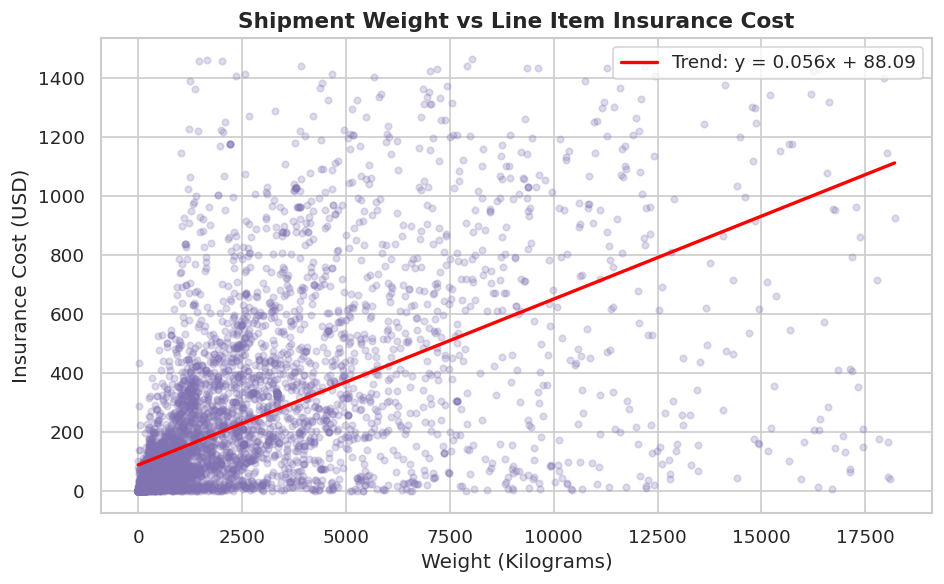

Correlation: 0.586


In [32]:
# ── Chart 19: Weight vs Insurance Cost ───────────────────────────
ins_df = df[df['Weight (Kilograms)'].notna() &
            (df['Line Item Insurance (USD)'] > 0) &
            (df['Weight (Kilograms)'] < df['Weight (Kilograms)'].quantile(0.97)) &
            (df['Line Item Insurance (USD)'] < df['Line Item Insurance (USD)'].quantile(0.97))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ins_df['Weight (Kilograms)'], ins_df['Line Item Insurance (USD)'],
           alpha=0.25, s=15, color='#8172B2')
# Regression line
m, b = np.polyfit(ins_df['Weight (Kilograms)'], ins_df['Line Item Insurance (USD)'], 1)
xline = np.linspace(ins_df['Weight (Kilograms)'].min(), ins_df['Weight (Kilograms)'].max(), 200)
ax.plot(xline, m*xline + b, color='red', linewidth=2, label=f'Trend: y = {m:.3f}x + {b:.2f}')
ax.set_title('Shipment Weight vs Line Item Insurance Cost', fontsize=13, fontweight='bold')
ax.set_xlabel('Weight (Kilograms)')
ax.set_ylabel('Insurance Cost (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Correlation: {ins_df['Weight (Kilograms)'].corr(ins_df['Line Item Insurance (USD)']):.3f}")


##### 1. Why did you pick the specific chart?

A **Scatter Plot with Regression Line** quantifies the linear relationship between weight and insurance cost, directly answering the project's business question about insurance cost drivers.

##### 2. What is/are the insight(s) found from the chart?


- There is a **positive linear relationship** between weight and insurance cost, confirming that heavier shipments incur higher insurance.
- However, scatter is substantial — weight alone explains only part of insurance cost (Line Item Value is a stronger driver at 0.96 correlation).
- Some lightweight shipments still carry high insurance — likely high-value compact pharmaceuticals.


##### 3. Business Impact

Insurance cost models should primarily use Line Item Value rather than weight as the predictor variable. This can help FedEx provide more accurate freight quotes with insurance bundled.

#### Chart - 20 : Median Freight Cost by Shipment Mode × Product Group (Heatmap)

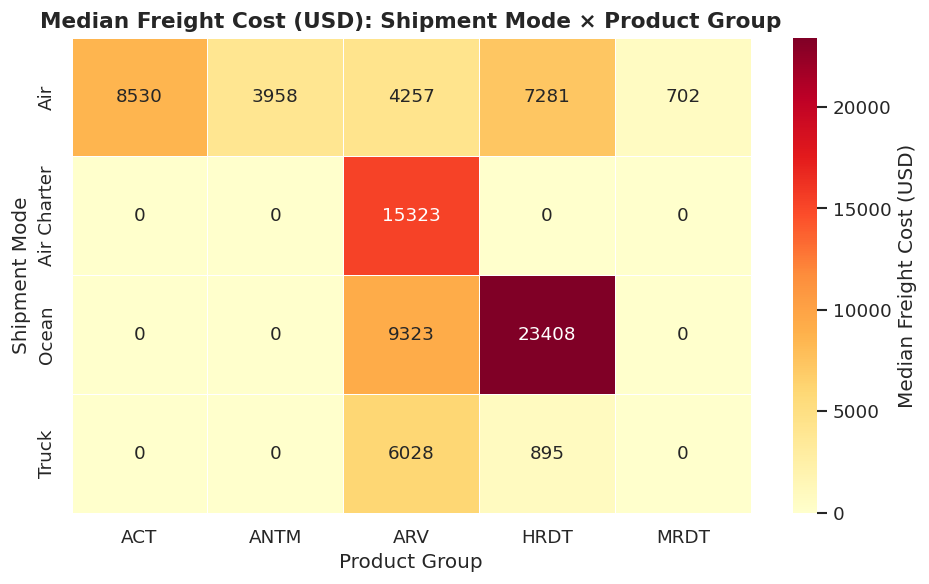

In [33]:
# ── Chart 20: Multivariate Heatmap ───────────────────────────────
pivot = (df[df['Freight Cost (USD)'].notna() & (df['Shipment Mode'] != 'Unknown')]
         .groupby(['Shipment Mode','Product Group'])['Freight Cost (USD)']
         .median().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Median Freight Cost (USD)'})
ax.set_title('Median Freight Cost (USD): Shipment Mode × Product Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Shipment Mode')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A **Pivot Heatmap** is the ideal multivariate chart for a numerical outcome (freight cost) across two categorical dimensions (mode × product group). Color intensity immediately reveals cost hotspots.

##### 2. What is/are the insight(s) found from the chart?


- **Air Charter × ARV** represents the highest median freight cost — a critical cost hotspot.
- **Ocean** consistently shows low freight costs across all product groups.
- **HRDT** products sent via Air Charter also show elevated costs despite being test kits (compact items).
- **Truck** remains cost-efficient for ARV products sourced from RDC warehouses.


##### 3. Business Impact

This chart directly guides cost optimization decisions: specifically, ARV shipments via Air Charter should be audited and, where possible, converted to standard Air or Ocean freight. This single intervention could yield the largest freight savings.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective?


Based on the comprehensive EDA performed on FedEx's SCMS Delivery History dataset, the following recommendations are made:

**1. Expand RDC (Regional Distribution Center) Coverage**
The single strongest lever for improving delivery reliability. Shipments fulfilled via RDC have ~50% lower delay rates than Direct Drop. Priority expansion countries: Nigeria, Côte d'Ivoire, and Haiti.

**2. Restrict Air Charter Usage**
Air Charter is both the most expensive (per KG) and has the highest delay rate (~17%). Implement an approval gate requiring justification before booking Air Charter. Standard Air should be the default for urgent shipments.

**3. Shift Eligible Cargo to Ocean/Truck**
For ARV products with long shelf lives and non-urgent delivery windows, Ocean and Truck offer significant freight savings. A 10% modal shift from Air to Truck/Ocean on eligible shipments could save millions in annual freight costs.

**4. Introduce SLA Tiers for First-Line Drugs**
First-line designation drugs currently receive no special logistics priority despite their critical importance to treatment outcomes. Introduce SLA monitoring with escalation protocols for first-line ARV products.

**5. Standardize Lead Time Planning**
The bimodal lead time distribution suggests two different procurement tracks operating in parallel without a unified standard. Harmonizing PO-to-delivery lead time windows to 80-120 days (with exceptions for emergency orders) would improve planning consistency.

**6. Country-Level Risk Management**
Countries with delay rates significantly above average should have dedicated logistics risk reviews. Options include pre-positioning stock, identifying alternative last-mile partners, and working with customs brokers to reduce clearance times.

**7. Insurance Cost Optimization**
Since Line Item Value (not weight) is the primary driver of insurance costs, insurance brackets should be recalibrated against shipment value bands — potentially reducing over-insurance for low-value heavy shipments.


# **Conclusion**


This EDA on the FedEx SCMS Delivery History Dataset has surfaced the following key conclusions:

1. **Overall Delivery Performance is Good but Not Uniform:** 88.5% on-time rate is commendable, but the 11.5% delay rate for critical pharmaceuticals represents a meaningful risk. Delays are unevenly distributed across countries, shipment modes, and fulfillment methods.

2. **Fulfillment Method is the Strongest Driver of Reliability:** RDC-based fulfillment dramatically outperforms Direct Drop in on-time delivery. Expanding pre-positioned inventory is the single highest-impact operational change available.

3. **Air Charter is a Cost-Reliability Paradox:** Despite being the most expensive mode, it has the highest delay rate — suggesting that its use is being driven by urgency situations that often still don't result in on-time delivery.

4. **Dataset is Heavily ARV-Focused:** ~83% of all shipments are ARV products for HIV treatment programs. Analysis of other product groups (ACT, ANTM) is limited by sample size and should not be generalized.

5. **No Single Numeric Feature Predicts Delays:** Delivery delay has very weak correlation with all numeric features. Categorical factors (country, mode, INCO term, fulfillment method) are more predictive — suggesting a classification model using these features would be the logical next step.

6. **Weight-Freight-Insurance Relationships are Predictable:** Strong correlations between shipment weight, freight cost, and insurance value are well-established. These relationships can be used to build cost forecasting models to improve procurement budgeting.

**Overall, FedEx's logistics network for this pharmaceutical supply chain is functional and largely reliable, but significant cost and reliability improvements are available through modal optimization, RDC expansion, and country-specific risk management programs.**


### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***